# Lab 1 Part A: OOP Search Algorithms for Drone Pathfinding

**Duration:** 1 week  
**Course topic:** Uninformed Search and Problem Formulation  
**Algorithms:** BFS, DFS, DLS, and IDS  
**Programming style:** Object-Oriented Python

---

## Scenario

You are programming the pathfinding logic of an autonomous drone used for environmental monitoring. The drone surveys difficult terrain to detect environmental degradation, such as illegal small-scale mining activities.

The drone must navigate from a designated **start location** to a **goal location** while avoiding obstacles such as:

- dense forests,
- water bodies,
- dangerous pits,
- restricted zones.

You will model the environment as a **search problem** and implement several search algorithms using an OOP design similar to the AIMA-style pseudocode for `BREADTH-FIRST-SEARCH(problem)` and `EXPAND(problem, node)`.

The goal of this lab is not just to get a path. The goal is to understand how different search strategies behave when the same problem object is passed to them.

# Learning Objectives

By the end of this lab, you should be able to:

1. Formulate a grid navigation task as a formal search problem.
2. Explain the roles of **state**, **action**, **result**, **path cost**, **frontier**, and **reached/explored set**.
3. Implement a reusable `Problem` interface and a `Node` class.
4. Implement and compare:
   - Breadth-First Search (BFS),
   - Depth-First Search (DFS),
   - Depth-Limited Search (DLS),
   - Iterative Deepening Search (IDS).
5. Evaluate algorithms using:
   - solution depth,
   - path cost,
   - number of nodes expanded,
   - maximum frontier/stack size,
   - completeness and optimality.
6. Explain when BFS, DFS, DLS, and IDS are complete or optimal on an unweighted grid.


# Submission Instructions

Complete all code cells marked with `TODO`.

Your final notebook must include:

1. Completed implementations of `GridProblem`, `expand`, BFS, DFS, DLS, and IDS.
2. Output tables comparing the algorithms.
3. Visualisations of at least two solution paths.
4. Answers to all reflection questions.
5. At least two additional maps created by you.
6. An **AI Use Declaration**, whether or not you used an AI tool.

Save your completed notebook as:

```text
FirstName_LastName_Lab_1A.ipynb
```

---

## GitHub Submission

You are required to submit your work through GitHub.

1. Create a GitHub repository for this lab.
2. Add your completed notebook to the repository.
3. Add your **AI Use Declaration** to the repository. This may be included inside the notebook or added as a separate file named `AI_USE_DECLARATION.md`.
4. Commit and push your final solution to GitHub.
5. Make sure the repository is **public** so that it can be accessed and graded.
6. Submit the **GitHub repository link** on Canvas.

Do **not** submit only the `.ipynb` file on Canvas. Canvas should contain the link to your public GitHub repository.

---

## AI Use Declaration Requirement

If you use any AI tool while completing this lab, you must declare it clearly. Examples of AI tools include ChatGPT, Claude, Gemini, Copilot, Perplexity, CodeWhisperer, or any other AI coding or writing assistant.

Your AI use must **not exceed 25% of the entire work**. The main implementation, debugging, explanation, testing, and final decisions must be your own.

Your declaration must include:

1. The **name of the AI tool** used.
2. The **purpose** for which it was used.
3. The **prompts or instructions** given to the tool, where applicable.
4. The **specific parts of the work influenced** by the tool.
5. A short explanation of how you **verified, edited, corrected, tested, or improved** the AI-generated output.

If you did not use any AI tool, write:

```text
I did not use any AI tool to complete this lab.
```

### Attachment of AI Output

Where required by the lecturer, you must attach evidence of AI use. Evidence may include:

- AI-generated drafts,
- prompt history,
- screenshots,
- exported conversations,
- AI-generated code snippets,
- revised versions showing your own input and improvements.

The evidence should make it clear what the AI produced and what you personally changed, tested, corrected, or improved.


---

## Final Submission Checklist

Before submitting, confirm that:

- your notebook opens correctly on GitHub,
- all completed code cells are visible,
- the notebook runs from top to bottom without errors,
- your answers to the reflection questions are included,
- your AI Use Declaration is included,
- any required evidence of AI use is attached,
- your AI use does not exceed 25% of the entire work,
- the repository is public,
- the repository link is accessible without requiring permission.


# 0. How the OOP Design Maps to Search Pseudocode

The search pseudocode uses abstract operations such as `problem.ACTIONS(s)`, `problem.RESULT(s, action)`, and `problem.IS-GOAL(s)`.

In this notebook, these become methods of a `Problem` object.

| Search pseudocode concept | Python/OOP equivalent |
|---|---|
| `problem.INITIAL` | `problem.initial_state()` |
| `problem.IS-GOAL(s)` | `problem.is_goal(state)` |
| `problem.ACTIONS(s)` | `problem.actions(state)` |
| `problem.RESULT(s, action)` | `problem.result(state, action)` |
| `problem.ACTION-COST(s, action, s')` | `problem.action_cost(state, action, next_state)` |
| `NODE(...)` | `Node(...)` dataclass |
| `frontier` | queue, stack, priority queue, or recursion stack |
| `reached` | set or dictionary that prevents unnecessary revisiting |
| `EXPAND(problem, node)` | `SearchAlgorithm.expand(problem, node)` |

This separation is important:

> The `GridProblem` knows the drone environment.  
> The search algorithms know how to search.  
> The `Node` stores the search tree information needed to reconstruct a solution path.

# 1. Setup and Imports

Run the cell below before starting the lab.

In [60]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 2. The Abstract `Problem` Interface

Every search problem must provide the same basic operations.

This lets us write search algorithms that do not depend on the specific problem domain.
The same BFS class should work for a drone map, a road network, a puzzle, or a game state space.

In [61]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

# 3. The `Node` Class

A state alone is not enough to reconstruct the solution.

A `Node` stores:

- the current state,
- the parent node,
- the action that generated the node,
- the path cost from the start state,
- the depth of the node in the search tree.

This matches the pseudocode:

```text
NODE(STATE=s', PARENT=node, ACTION=action, PATH-COST=cost)
```

In [62]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

# 4. Helper Functions

These helper functions are provided for you.

You will use them to:

- reconstruct paths,
- check for cycles on a single path,
- convert search results into a table.

In [63]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

# 5. Implementing the Grid Search Problem

In this lab, a state is represented as a tuple:

```python
(row, col)
```

For example:

```python
(0, 0)
```

means row 0, column 0.

The grid uses:

| Cell value | Meaning |
|---|---|
| `0` | Free cell |
| `1` | Obstacle |

The actions are movement directions:

```python
"UP", "DOWN", "LEFT", "RIGHT"
```

Your `GridProblem.actions(state)` method should return only the movements that are legal from the current state.
A move is legal only if the resulting cell is:

1. inside the grid,
2. not an obstacle.

## 5.1 Self-Check for `GridProblem`

Run this after completing `GridProblem`.

The test grid is:

```text
S . .
# # .
. . G
```

Expected behaviour:

- Start: `(0, 0)`
- Goal: `(2, 2)`
- From `(0, 0)`, the only legal action is `"RIGHT"`
- Applying `"RIGHT"` from `(0, 0)` gives `(0, 1)`

In [64]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions: List[Tuple[int, int]] = []
        # 2. For each action in MOVES:
        for action in MOVES:
        #       a. Compute the neighbour cell.
            state_row, state_col = state
            neighbor_state = (state_row + MOVES.get(action)[0],state_col + MOVES.get(action)[1])
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
            if self.in_bounds(neighbor_state) and self.is_free(neighbor_state):
                 legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        state_row, state_col = state
        action_row, action_col = MOVES[action]

        shift_row = state_row+action_row
        shift_col = state_col+action_col

        shift_state = (shift_row, shift_col)
        # return (row + dr, col + dc)
        return shift_state
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

In [65]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


# 6. Sample Drone Map

The map below is provided so your lab can run without depending on an internet connection.

You may still create your own maps later.

In [66]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

# 7. Visualisation Helper

The function below plots:

- obstacles as dark cells,
- the start position,
- the goal position,
- the solution path.

You do not need to modify this function.

In [67]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

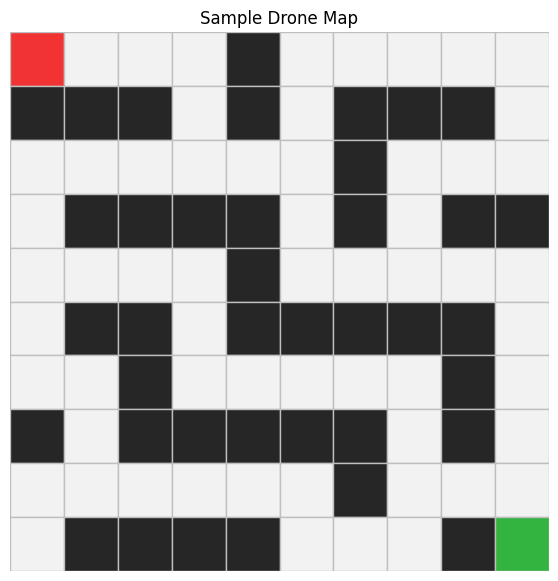

In [68]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

# 8. The Shared `expand` Method

The pseudocode has a separate `EXPAND(problem, node)` function.

In this OOP design, all search algorithms inherit a common `expand` method.

Complete this method once, then reuse it in BFS, DFS, DLS, and IDS.

The method should:

1. get the current state from the node,
2. ask the problem for legal actions,
3. generate the resulting child state for each action,
4. compute the new path cost,
5. yield a new `Node`.

In [69]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:

        # s <- node.STATE
        gen_nodes = []
        current_state = node.state
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(current_state):
        #     s_prime <- problem.RESULT(s, action)
              next_state = problem.result(current_state, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
              path_cost = node.path_cost + problem.action_cost(current_state, action, next_state)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
              gen_node = Node(state=next_state, parent=node, action=action, path_cost=path_cost)
              gen_nodes.append(gen_node)
        return gen_nodes
        raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

# 9. Breadth-First Search (BFS)

BFS expands nodes in order of increasing depth.

It uses a **FIFO queue**:

- add new nodes at the back,
- remove nodes from the front.

BFS is complete for finite branching factors.  
BFS is optimal when every step has the same cost.

## Your task

Complete the `BreadthFirstSearch.search` method.

## BFS Pseudocode Guide

Study this pseudocode before completing the BFS code cell below. Try to match each pseudocode line to a Python statement in your implementation.

```text
BREADTH-FIRST-SEARCH(problem)
    node ← NODE(problem.INITIAL)

    if problem.IS-GOAL(node.STATE) then
        return node

    frontier ← a FIFO queue with node as an element
    reached ← {problem.INITIAL}

    while frontier is not empty do
        node ← POP(frontier)          // remove from the front of the queue

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if problem.IS-GOAL(s) then
                return child

            if s is not in reached then
                add s to reached
                add child to frontier // add to the back of the queue

    return failure
```

**Python structure to think about:** BFS uses `deque`, `popleft()`, and `append()`.


In [70]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        search_result  = SearchResult(algorithm="BFS", status="failure", max_frontier_size=0, nodes_expanded=0, reached_count=0, limit=0, solution = None)
        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        init_node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(init_node):
           search_result.status = "success"
           search_result.solution = init_node
           return search_result
        # 3. Create a deque frontier and add the initial node.
        frontier = deque()
        frontier.append(init_node)
        # 4. Create a reached set and add the initial state.
        reached_set = {problem.initial_state()}
        frontier_size = 0
        # 5. While frontier is not empty:
        while len(frontier) > 0:
        #       a. pop from the LEFT of the deque.
                working_node = frontier.popleft()
        #       b. increment nodes_expanded.
                search_result.nodes_expanded += 1
        #       c. expand the node.
                child_nodes = self.expand(problem, working_node)
        #       d. for each child:
                for child in child_nodes:
        #            i. if child is goal, return success.
                     if problem.is_goal(child.state):
                        search_result.status = "success"
                        search_result.solution = child
                        break
        #           ii. if child.state is not in reached:
                     if child.state not in reached_set:
        #                  add child.state to reached.
                           reached_set.add(child.state)
        #                  append child to frontier.
                           frontier.append(child)
                           search_result.reached_count += 1
                           frontier_size = len(frontier)
        #       e. update max_frontier_size.
                if frontier_size > search_result.max_frontier_size:
                    search_result.max_frontier_size = frontier_size
        # 6. Return failure if no solution is found.
        return search_result
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        raise NotImplementedError("Complete BreadthFirstSearch.search")

# 10. Depth-First Search (DFS)

DFS expands the deepest node on the frontier first.

It uses a **LIFO stack**:

- push new nodes onto the stack,
- pop the most recently added node.

DFS is memory-efficient in some cases, but it is not generally optimal.
In infinite state spaces or spaces with cycles, DFS can fail to terminate unless cycle handling or depth limits are used.

## Your task

Complete the `DepthFirstSearch.search` method.

## DFS Pseudocode Guide

Study this pseudocode before completing the DFS code cell below. Notice that DFS uses a stack instead of a queue.

```text
DEPTH-FIRST-SEARCH(problem)
    node ← NODE(problem.INITIAL)

    if problem.IS-GOAL(node.STATE) then
        return node

    frontier ← a LIFO stack with node as an element
    reached ← {problem.INITIAL}

    while frontier is not empty do
        node ← POP(frontier)          // remove from the top/end of the stack

        for each child in EXPAND(problem, node) do
            s ← child.STATE

            if problem.IS-GOAL(s) then
                return child

            if s is not in reached then
                add s to reached
                PUSH child onto frontier

    return failure
```

**Python structure to think about:** DFS can use a normal list, with `append()` to push and `pop()` to remove the most recently added node.


In [71]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        search_result  = SearchResult(algorithm="DFS", status="failure", max_frontier_size=0, solution=None,nodes_expanded=0, reached_count=0, limit=0)

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        init_node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(problem.initial_state()):
          search_result.status = "success"
          search_result.solution = init_node
          return search_result
        # 3. Use a Python list as the stack frontier.
        frontier = [init_node]
        # 4. Use a reached set.
        reached_set = {init_node.state}
        # 5. While frontier is not empty:
        frontier_size = 0
        while len(frontier) != 0:
        #       a. pop from the end of the list.
           working_node = frontier.pop()
        #       b. increment nodes_expanded.
           search_result.nodes_expanded += 1
        #       c. expand the node.
           child_nodes = self.expand(problem, working_node)
        #       d. add unreached children to the stack.
           for child in child_nodes:
               if problem.is_goal(child.state):
                   search_result.status = "success"
                   search_result.solution = child
                   break
               if child.state not in reached_set:
                  reached_set.add(child.state)
                  frontier.append(child)
                  frontier_size = len(frontier)

        #       e. update max_frontier_size.
           if frontier_size > search_result.max_frontier_size:
              search_result.max_frontier_size = frontier_size
           search_result.reached_count = len(reached_set)
        return search_result
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        raise NotImplementedError("Complete DepthFirstSearch.search")

# 11. Depth-Limited Search (DLS)

Depth-Limited Search is DFS with a maximum depth limit.

DLS is useful when:

- the state space may be very deep,
- DFS may go down an unhelpful branch,
- we want to restrict the search depth.

DLS can return three statuses:

| Status | Meaning |
|---|---|
| `"success"` | A solution was found |
| `"cutoff"` | The search reached the depth limit before proving failure |
| `"failure"` | No solution exists within the explored part and no cutoff occurred |

## Important note about repeated states

For DLS, use **path-cycle checking** rather than a global reached set.  
This means you should avoid adding a child if its state already appears on the current path from the root to the current node.

Use this helper:

```python
state_is_on_path(node, child.state)
```

## DLS Pseudocode Guide

Study this pseudocode before completing the recursive DLS code cell below. DLS behaves like DFS, but it refuses to search beyond a given depth limit.

```text
DEPTH-LIMITED-SEARCH(problem, limit)
    node ← NODE(problem.INITIAL)
    return RECURSIVE-DLS(node, problem, limit)

RECURSIVE-DLS(node, problem, limit)
    if problem.IS-GOAL(node.STATE) then
        return node, success

    else if node.DEPTH ≥ limit then
        return null, cutoff

    else
        cutoff_occurred ← false

        for each child in EXPAND(problem, node) do
            if child.STATE is already on the current path then
                skip this child

            result, status ← RECURSIVE-DLS(child, problem, limit)

            if status = success then
                return result, success

            else if status = cutoff then
                cutoff_occurred ← true

        if cutoff_occurred then
            return null, cutoff
        else
            return null, failure
```

**Python structure to think about:** DLS is naturally implemented using a helper method such as `_recursive_dls(...)`.


In [72]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
           return (node, "success")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return (None, "cutoff")
        # 3. Otherwise:
        else:
        #       a. increment metrics["nodes_expanded"].
            metrics["nodes_expanded"] += 1
        #       b. set cutoff_occurred = False.
            cutoff_occurred = False
        #       c. for each child in expand(problem, node):
            child_nodes = self.expand(problem, node)
            for child in child_nodes:
        #             i. skip the child if child.state already appears on the current path.
                if state_is_on_path(node, child.state):
                  continue
        #            ii. update max_stack_size.
                metrics["max_stack_size"] = current_stack_size
        #           iii. recursively call _recursive_dls on the child.
                result, status = self._recursive_dls(problem=problem, node=child, limit=limit, current_stack_size=current_stack_size+1, metrics=metrics)
        #            iv. if result is "success", return success immediately.
                if status == "success":
                   return(result, status)
        #             v. if result is "cutoff", set cutoff_occurred = True.
                if status == "cutoff":
                   cutoff_occurred = True
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        if cutoff_occurred:
           return(None, "cutoff")
        #             else return (None, "failure")
        return(None, "failure")
        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

# 12. Iterative Deepening Search (IDS)

IDS repeatedly runs DLS with increasing depth limits.

It tries:

```text
limit = 0
limit = 1
limit = 2
limit = 3
...
```

IDS combines some strengths of BFS and DFS:

- It is complete for finite branching factor search spaces.
- It is optimal when step costs are uniform.
- It uses memory similar to DFS.
- It may expand shallow nodes several times.

## Your task

Complete `IterativeDeepeningSearch.search`.

## IDS Pseudocode Guide

Study this pseudocode before completing the IDS code cell below. IDS repeatedly calls DLS with increasing limits.

```text
ITERATIVE-DEEPENING-SEARCH(problem, max_depth)
    for limit from 0 to max_depth do
        result, status ← DEPTH-LIMITED-SEARCH(problem, limit)

        record the limit and status in the iteration log

        if status = success then
            return result

        else if status = failure then
            return failure

    return cutoff
```

**Python structure to think about:** IDS should create a `DepthLimitedSearch` object and call `dls.search(problem, limit=limit)` inside a loop.


In [73]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"
        search_result  = SearchResult(algorithm="IDS", status="failure", max_frontier_size=0, nodes_expanded=0, reached_count=0, limit=0, solution=None)
        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        iteration_log = []
        accumulated_expanded_nodes = 0
        max_stack_size = 0
        # 1. Keep a list called iteration_log.
        for limit in range(1, max_depth+1):
          dls = DepthLimitedSearch()
          dls_result = dls.search(problem, limit)

          iteration_log.append({
              'limit': dls_result.limit,
              'status': dls_result.status,
              'nodes expanded': dls_result.nodes_expanded
          })
        # 2. Accumulate total nodes expanded across all DLS iterations.
          accumulated_expanded_nodes += dls_result.nodes_expanded
        # 3. Track the maximum stack size seen in any DLS run.
          max_stack_size = dls_result.max_frontier_size if max_stack_size < dls_result.max_frontier_size else max_stack_size
        # 4. If a DLS run returns success, return a SearchResult for IDS.
          if dls_result.status == "success":
            search_result.solution = dls_result.solution
            search_result.status = "success"
            search_result.max_frontier_size = max_stack_size
            search_result.nodes_expanded = accumulated_expanded_nodes
            search_result.limit = limit
            search_result.iterations = iteration_log
            return search_result
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
          if dls_result.status == "failure":
            search_result.solution = dls_result.solution
            search_result.status = "failure"
            search_result.max_frontier_size = max_stack_size
            search_result.nodes_expanded = accumulated_expanded_nodes
            search_result.limit = limit
            search_result.iterations = iteration_log
            return search_result
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        search_result.status = "cutoff"
        search_result.max_frontier_size = max_stack_size
        search_result.nodes_expanded = accumulated_expanded_nodes
        search_result.limit = limit
        search_result.iterations = iteration_log
        return search_result
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

# 13. Run the Algorithms on the Sample Map

Complete all algorithm classes before running this section.

For DLS, choose a depth limit. Try a limit that is too small first, then a limit that is large enough.

In [74]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,0,18.0,18.0,60,5,59
1,DFS,success,0,18.0,18.0,60,4,60
2,DLS,cutoff,10,NaN,NaN,16,10,0
3,IDS,success,18,18.0,18.0,356,18,0


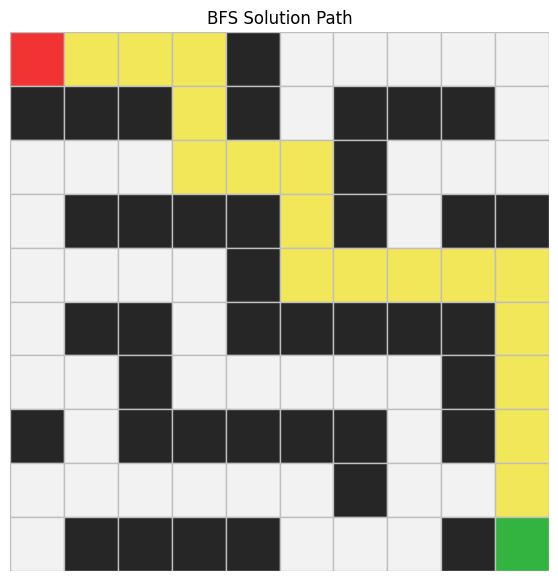

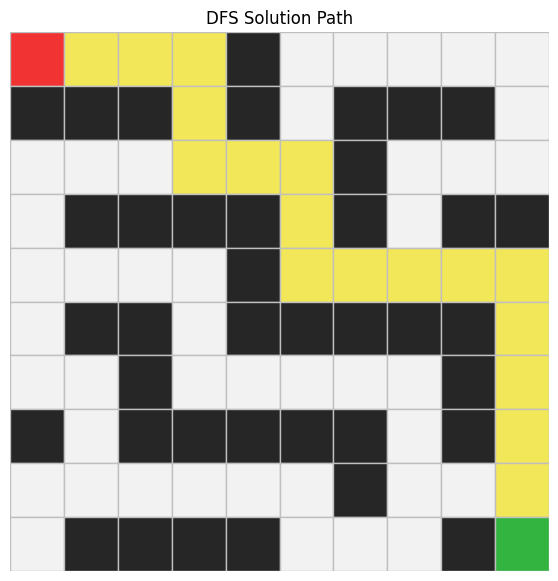

In [75]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


# 14. Create Your Own Maps

Create at least **two additional maps**.

Your maps should be meaningfully different. For example:

1. A map with a long narrow corridor.
2. A map with many dead ends.
3. A map where DFS is likely to enter dead ends before finding the goal.
4. A larger map, such as 15 × 15 or 20 × 20.

For each map:

- run BFS, DFS, DLS, and IDS,
- record the metrics,
- visualise at least one solution path,
- write a short interpretation.


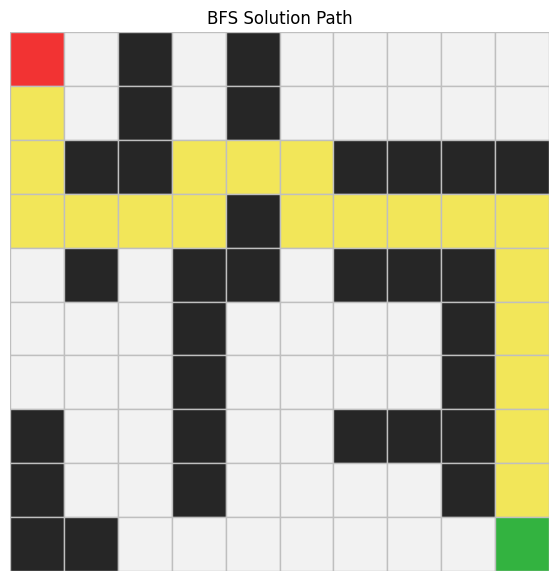

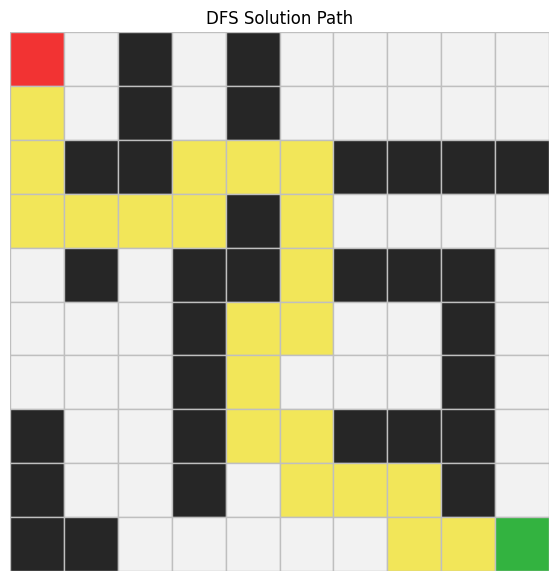

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,0,20,20,68,10,67
1,DFS,success,0,22,22,68,10,68
2,DLS,success,20,20,20,80,20,0
3,IDS,success,18,18,18,3240,18,0


In [76]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,1,0,1,0,0,0,0,0],
    [0,0,1,0,1,0,0,0,0,0],
    [0,1,1,0,0,0,1,1,1,1],
    [0,0,0,0,1,0,0,0,0,0],
    [0,1,0,1,1,0,1,1,1,0],
    [0,0,0,1,0,0,0,0,1,0],
    [0,0,0,1,0,0,0,0,1,0],
    [1,0,0,1,0,0,1,1,1,0],
    [1,0,0,1,0,0,0,0,1,0],
    [1,1,0,0,0,0,0,0,0,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (9,9)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=25),
 ]
plot_path(
    custom_grid_1,
    (0,0),
    goal=(9,9),
    path=custom_results_1[0].path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    (0,0),
    goal=(9,9),
    path=custom_results_1[1].path,
    title="DFS Solution Path",
)
show_results(custom_results_1)

##Intepretation
The map is 10x10 grid. As shown through the solution path on the visualization, BFS provides a shorter path cost than DFS, despite expanding the same number of nodes. IDS produces a similar solution cost as BFS, but expands far more nodes. Of all methods, IDS produces the path with lowest cost but expands the most, taking the largest portion to derive.

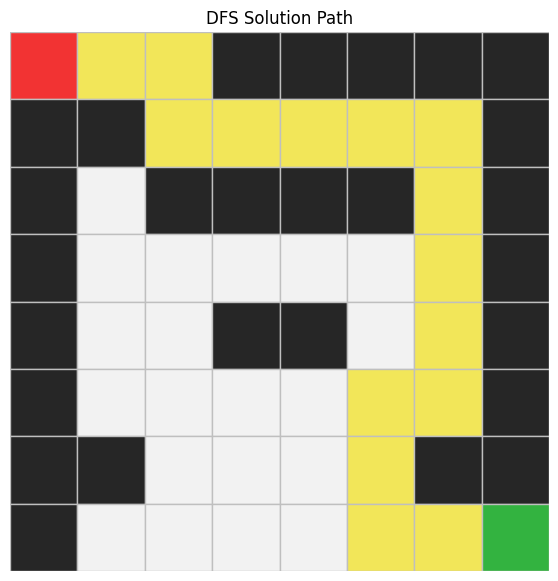

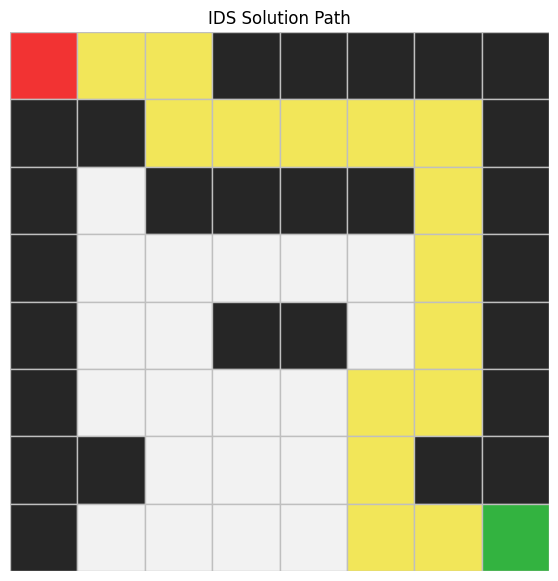

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,0,16,16,36,6,35
1,DFS,success,0,24,24,36,9,36
2,DLS,success,20,16,16,57,16,0
3,IDS,success,16,16,16,211,16,0


In [77]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 1, 1, 1, 1, 1],
    [1, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 1, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 0, 0, 0, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0]
]

custom_start_2 = (0,0)
custom_goal_2 = (7,7)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
     ids.search(custom_problem_2, max_depth=40),
]



plot_path(
    custom_grid_2,
    (0,0),
    goal=(7,7),
    path=custom_results_2[2].path,
    title="DFS Solution Path",
)
plot_path(
    custom_grid_2,
    (0,0),
    goal=(7,7),
    path=custom_results_2[3].path,
    title="IDS Solution Path",
)
show_results(custom_results_2)

##Interpretation
This map is an 8x8 grid. BFS, DLS, and IDS produce similar path cost, but with increasing number of nodes expanded. However, DFS produces a solution with a much a higher path cost, but similar number of nodes expanded as BFS. It can also be observed that BFS, DLS, and IDS follow similar paths.

# 15. Reflection Questions

Answer the questions below in markdown cells.

## 15.1 Problem Formulation

1. What is a state in this lab?
2. What is an action?
3. What does the `result` function do?
4. Why is it useful to separate the problem definition from the search algorithm?

## 15.2 BFS

1. Why does BFS use a FIFO queue?
2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
3. What role does the `reached` set play in BFS?

## 15.3 DFS

1. Why does DFS use a stack?
2. Is DFS guaranteed to find the shortest path? Explain.
3. Under what conditions can DFS use less memory than BFS?
4. Under what conditions can DFS perform badly?

## 15.4 DLS

1. What happens when the depth limit is too small?
2. What is the meaning of `"cutoff"`?
3. How is DLS different from ordinary DFS?
4. Why do we use path-cycle checking in DLS?

## 15.5 IDS

1. Why does IDS repeat DLS with increasing limits?
2. Why can IDS be complete even though DLS with a small limit is not?
3. Why does IDS use less memory than BFS?
4. What is the cost of repeatedly searching from the root?

## 15.6 Real-World Drone Context

1. In a real drone application, what might make one route safer or more practical than another?
2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
4. What limitations does this grid model have compared with real drone navigation?


##Reflection Solution

##15.1 Problem Formulation
1. A state is the co-ordinates that represent the current location of the drone throughout the map, which is represented by the grid. The co-ordinates consist of the row and column ordinates.
2. An action is a change in one of the ordinates that come together to form the state. This can be a subtraction or addition to represent up, down, left or right movement of the drone.
3. The result function takes an action and a state to produce a state that results from the action. Particularly, it performs the addition or subtraction of ordinates. In other words, it is the transition function.
4. This allows the same problem to run across different search algorithmns for testing and comparison purposes. This prevents the redundancy of having to write the same problem for different algorithmns

##15.2 BFS
1. BFS uses a FIFO queue as a frontier, because, when it comes to selection of a node for expansion, it picks the first node to entered and adds new nodes to the end. This means that nodes that child nodes at deeper depth are placed on hold within the frontier, while older nodes at the same depth as the just expanded node, are selected. This allows all nodes at the same level to be expanded before child nodes.
2. BFS explores nodes at shallower depths before exploring deeper depths, which means locations closer to initial state for unweighted grids. If the goal exists on a path at a shallower depth, that goal is reached before, if the goal exists at a deeper depth.
3. The reached set is a set of nodes that have previously explored. If a node appears in the reached set, the algorithmn is prevented from exploring it, preventing cyclic tendencies and redundant paths.

##15.3 DFS
1. DFS requires nodes at deeper depths to be explored before those at shallower depths of the search tree. Using a stack reads the most recently added nodes, because nodes removed from the end and added to the end.
2. DFS is not guaranteed to find the shortest path because, it selects the nodes at deeper depths, over those at shallower depths. This means it more likely choses path that lead to the goal state at deeper depth, in order words further from the initial.
3. DFS uses less memory than BFS on the condition it uses path cycle checking is used instead of a global reached set. This means it only maintains memory of the nodes at current branch being explored other than memory of every node explored.
4. DFS performs badly when the goal state is located close to the initial state. This is because the algorithmn explores the current branch until the lowest depth. In addition, if the algorithmn encounters a cyclic path without a reached set or path cycle checking, it remains in that state without termination.

##15.4 DLS
1. When the depth limit is too small, it forces the search to end, even if the goal or solution exists at a slightly lower depth.
2. "cutoff" occurs when the depth limit is reached without finding the solution. This means the search reached the maximum allowed depth for a path with discovering the goal state.
3. DLS uses a depth limit to force the search to end on a path when it reaches a certain depth. At shallow depth limit, it may even behave like BFS.
4. Path-cycle checking is more memory because it only the nodes on the current path it is exploring, while preventing cyclic tendencies and redundant paths.


##15.5 IDS
1. This is meant to overcome the limit of DLS and DFS where when the depth limit is too small, the search becomes incomplete. By cycling through a series of increasing depth limits, it is still possible to reach a goal state. At the same time, more shallow are forced to be explored before moving to lower depths.
2. IDS increasingly modifies depth limit. This allows the search to proceed beyond the limit enforced by the DLS. Therefore, if a solution lies beneath the small depth of the DLS, the IDS is more likely to discover it, completing the solution.
3. IDS implements path-cycle checking in a similar manner to DLS. Hence, the search only remembers when on the current path, without to save all explored members like in BFS.
4.  The cost of IDS is that in repeatedly searching from the root, it explores the nodes at shallower depths multiple times, which can cost a significant amount of time wastage in searching.

##15.6 Real-World Drone Context
1. In a real drone application, more pratical routes might have weather exposure factored in, where the routes without a strong wind turbulence or rain are safer. In addition, human activity are best to prevent accidental collisions. Lastly, higher altitude routes to avoid trees, power lines, etc and communication ranges and GPS signal availabilty.

2. BFS is the optimal if each step is of equal cost. This is because provided there is a goal state, BFS is guaranteed to the shortest path. IDS can also achieve the same, however because it explores the same nodes multiple, it is not very suitable for time critical situations. DLS is also not guaranteed to find the path if the depth limit is not sufficient.

3. DLS and IDS are very suitable to limit how far the drone searches, because both have a means to limit the depth of their searches. However, if you are certain of a particular limit, then DLS is the best choice, because IDS iterates over a range of limits up to the specified limit to find a goal, which would be meaningless in this situation.

4.
*   The movement of the drone in the grid is limited to four directions, which is discrete in a sense, whilst drone movement is real world is 360 degrees and continuous.
*   The environment in the grid is fixed in form, where obstacles remain where they are placed. On the other hand, the real world environment is subject to changes, which may be short-term.
*   The drone is capable of viewing the entire environment in the grid, whilst in the real world, the drone is limited by its sensor capabilities, and sometimes, real world obstacles.
Taking these account, the grid model is not very realistic.






# 16. Final Checklist

Before submitting, confirm that:

- [x] `GridProblem` is complete.
- [x] `SearchAlgorithm.expand` is complete.
- [x] BFS is complete.
- [x] DFS is complete.
- [x] DLS is complete.
- [x] IDS is complete.
- [x] You generated comparison tables.
- [x] You visualised solution paths.
- [x] You created at least two custom maps.
- [x] You answered all reflection questions.
- [x] Your notebook filename follows the required format.
